In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('Datasets\yelp_train.csv')

print(df.shape)
print(df.head(2))

<>:1: SyntaxWarning: invalid escape sequence '\y'
<>:1: SyntaxWarning: invalid escape sequence '\y'
C:\Users\dania\AppData\Local\Temp\ipykernel_10772\1698061552.py:1: SyntaxWarning: invalid escape sequence '\y'
  df = pd.read_csv('Datasets\yelp_train.csv')


(560000, 2)
                                                text  label
0  Unfortunately, the frustration of being Dr. Go...      0
1  Been going to Dr. Goldberg for over 10 years. ...      1


In [6]:
df.describe()

,label
count,560000.0
mean,0.5
std,0.5
min,0.0
25%,0.0
50%,0.5
75%,1.0
max,1.0


In [8]:
# Data quality check
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Data Types:
text     object
label     int64
dtype: object

Missing Values:
text     0
label    0
dtype: int64

Duplicates: 0


In [9]:
# Check class distribution in full dataset
print("Full Dataset Class Distribution:")
print(df['label'].value_counts())
print(f"\nBalance: {df['label'].value_counts(normalize=True)}")

Full Dataset Class Distribution:
label
0    280000
1    280000
Name: count, dtype: int64

Balance: label
0    0.5
1    0.5
Name: proportion, dtype: float64


In [10]:
# Stratified sampling: 50K per class
np.random.seed(42)

df_negative = df[df['label'] == 0].sample(n=50000, random_state=42)
df_positive = df[df['label'] == 1].sample(n=50000, random_state=42)

df_sample = pd.concat([df_negative, df_positive], ignore_index=True)
df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle

print(f"Sampled Dataset Shape: {df_sample.shape}")
print(f"Class Distribution:\n{df_sample['label'].value_counts()}")

Sampled Dataset Shape: (100000, 2)
Class Distribution:
label
1    50000
0    50000
Name: count, dtype: int64


In [11]:
# Save the 100K sample
df_sample.to_csv('Datasets/yelp_train_100k.csv', index=False)
print("Saved to 'Datasets/yelp_train_100k.csv'")

Saved to 'Datasets/yelp_train_100k.csv'


## Statistical Analysis and Visualizations

In [12]:
# STEP 3: Add text statistics
df_sample['char_count'] = df_sample['text'].str.len()
df_sample['word_count'] = df_sample['text'].str.split().str.len()
df_sample['avg_word_length'] = df_sample['char_count'] / df_sample['word_count']

print("Text Statistics Added:")
print(df_sample[['text', 'label', 'char_count', 'word_count', 'avg_word_length']].head())

Text Statistics Added:
                                                text  label  char_count  \
0  It's back up to the sexy five stars after my m...      1        2704   
1  What fascinates my boyfriend the most about th...      1        1746   
2  We've frequented this restaurant a number of t...      0        1935   
3  this is the neighborhood theater, super easy c...      1         301   
4  A very good friend and fellow foodie referred ...      1        1077   

   word_count  avg_word_length  
0         469         5.765458  
1         325         5.372308  
2         352         5.497159  
3          50         6.020000  
4         190         5.668421  


In [13]:
# Summary statistics by sentiment
print("\n" + "="*80)
print("TEXT LENGTH STATISTICS BY SENTIMENT")
print("="*80)

summary = df_sample.groupby('label')[['char_count', 'word_count', 'avg_word_length']].describe()
print(summary)


TEXT LENGTH STATISTICS BY SENTIMENT
      char_count                                                            \
           count       mean         std  min    25%    50%     75%     max   
label                                                                        
0        50000.0  825.33766  744.402827  1.0  326.0  605.0  1070.0  5132.0   
1        50000.0  633.99084  585.131016  1.0  244.0  461.0   830.0  5061.0   

      word_count             ...                avg_word_length            \
           count       mean  ...    75%     max           count      mean   
label                        ...                                            
0        50000.0  152.32826  ...  198.0  1015.0         50000.0  5.472590   
1        50000.0  114.90520  ...  151.0   998.0         50000.0  5.603333   

                                                             
             std  min       25%       50%       75%     max  
label                                                        


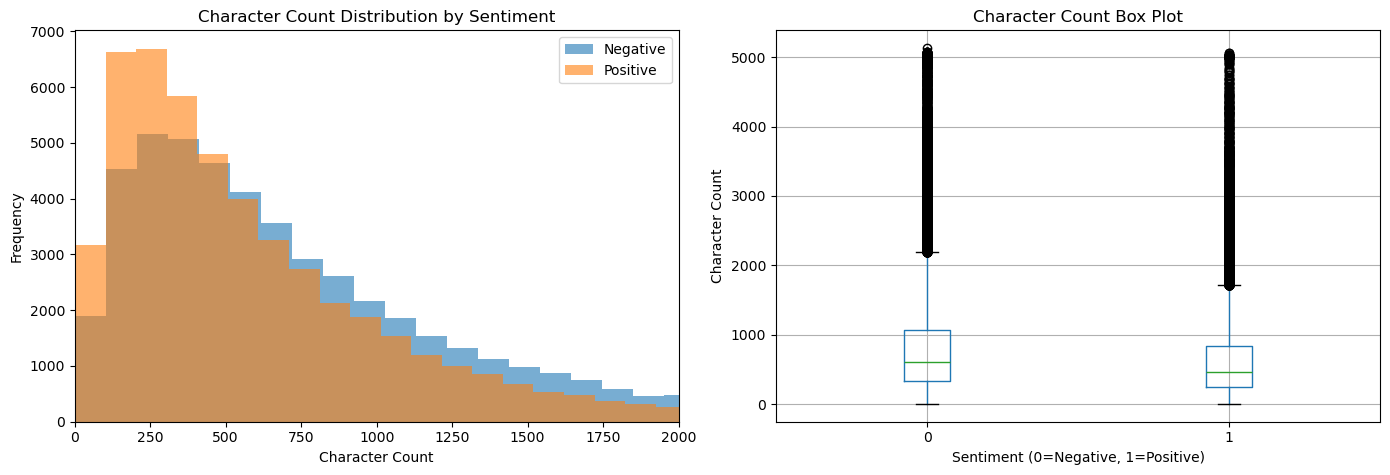

In [14]:
# STEP 4: Visualize character count distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for label in [0, 1]:
    data = df_sample[df_sample['label'] == label]['char_count']
    axes[0].hist(data, bins=50, alpha=0.6, label=f"{'Negative' if label==0 else 'Positive'}")
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Character Count Distribution by Sentiment')
axes[0].legend()
axes[0].set_xlim(0, 2000)  # Focus on main distribution

# Box plot
df_sample.boxplot(column='char_count', by='label', ax=axes[1])
axes[1].set_xlabel('Sentiment (0=Negative, 1=Positive)')
axes[1].set_ylabel('Character Count')
axes[1].set_title('Character Count Box Plot')
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

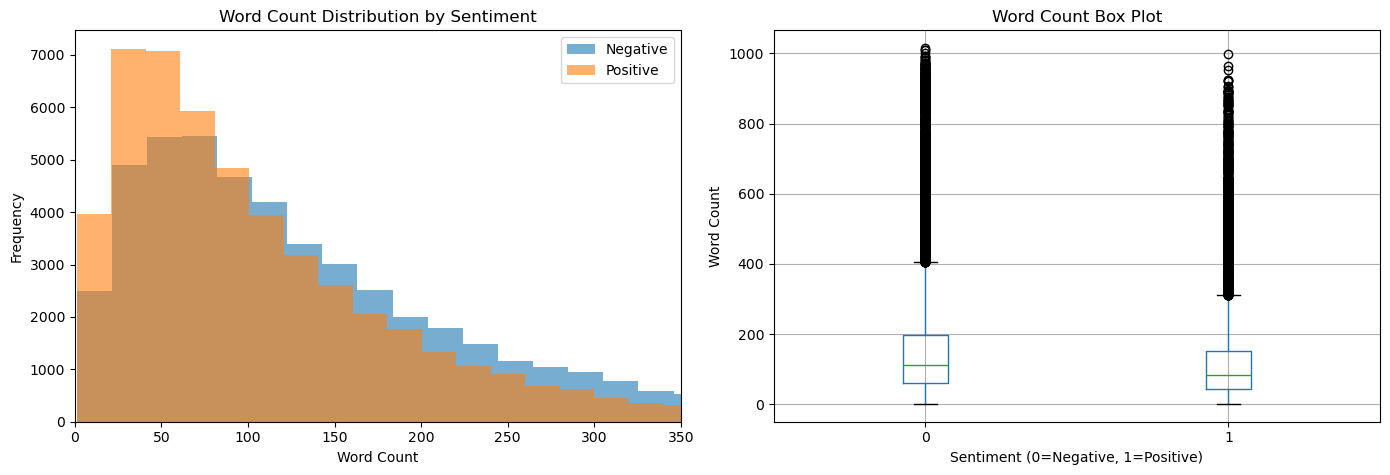

In [15]:
# Visualize word count distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for label in [0, 1]:
    data = df_sample[df_sample['label'] == label]['word_count']
    axes[0].hist(data, bins=50, alpha=0.6, label=f"{'Negative' if label==0 else 'Positive'}")
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Word Count Distribution by Sentiment')
axes[0].legend()
axes[0].set_xlim(0, 350)  # Focus on main distribution

# Box plot
df_sample.boxplot(column='word_count', by='label', ax=axes[1])
axes[1].set_xlabel('Sentiment (0=Negative, 1=Positive)')
axes[1].set_ylabel('Word Count')
axes[1].set_title('Word Count Box Plot')
plt.suptitle('')

plt.tight_layout()
plt.show()

## Vocabulary Analysis

In [17]:
import re
from collections import Counter
from nltk.corpus import stopwords

In [18]:
# Load English stopwords
stop_words = set(stopwords.words('english'))

def get_top_words(text_series, n=20):
    """Extract top N words after removing stopwords and cleaning"""
    all_words = []
    for text in text_series:
        # Lowercase and extract words
        words = re.findall(r'\b[a-z]{3,}\b', text.lower())  # min 3 chars
        # Remove stopwords
        words = [w for w in words if w not in stop_words]
        all_words.extend(words)
    
    # Count frequencies
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Extract top words for each sentiment
print("Extracting top words for negative reviews...")
negative_words = get_top_words(df_sample[df_sample['label']==0]['text'], n=20)

print("Extracting top words for positive reviews...")
positive_words = get_top_words(df_sample[df_sample['label']==1]['text'], n=20)

print("\n" + "="*80)
print("TOP 20 WORDS - NEGATIVE REVIEWS")
print("="*80)
for word, count in negative_words:
    print(f"{word:20s}: {count:6d}")

print("\n" + "="*80)
print("TOP 20 WORDS - POSITIVE REVIEWS")
print("="*80)
for word, count in positive_words:
    print(f"{word:20s}: {count:6d}")

Extracting top words for negative reviews...
Extracting top words for positive reviews...

TOP 20 WORDS - NEGATIVE REVIEWS
food                :  34450
place               :  29613
like                :  27300
get                 :  25415
would               :  25182
one                 :  24956
good                :  23816
service             :  22780
time                :  22175
back                :  21900
even                :  16862
really              :  15344
got                 :  14949
said                :  13819
never               :  13669
ordered             :  12558
could               :  12407
order               :  12391
came                :  12105
went                :  12069

TOP 20 WORDS - POSITIVE REVIEWS
good                :  30329
place               :  28207
great               :  28018
food                :  25039
like                :  19630
one                 :  17592
get                 :  17175
time                :  16699
really              :  15020
ser

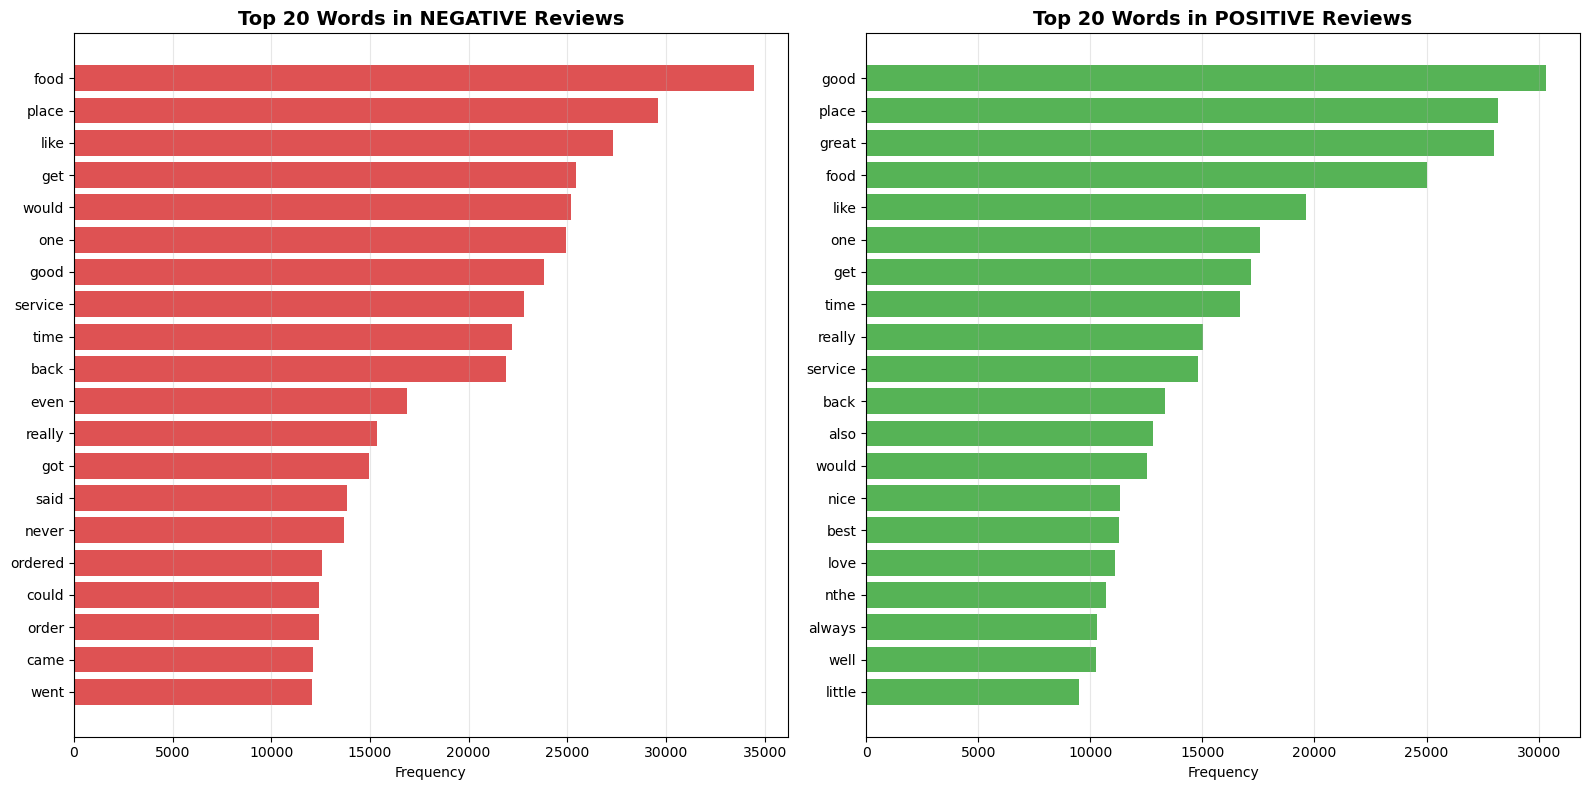


Chart saved as 'top_words_by_sentiment.png'


In [20]:
# STEP 6: Visualize top words with bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Negative words (left)
words_neg = [w[0] for w in negative_words]
counts_neg = [w[1] for w in negative_words]
axes[0].barh(words_neg, counts_neg, color='#d62728', alpha=0.8)
axes[0].set_xlabel('Frequency')
axes[0].set_title('Top 20 Words in NEGATIVE Reviews', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Positive words (right)
words_pos = [w[0] for w in positive_words]
counts_pos = [w[1] for w in positive_words]
axes[1].barh(words_pos, counts_pos, color='#2ca02c', alpha=0.8)
axes[1].set_xlabel('Frequency')
axes[1].set_title('Top 20 Words in POSITIVE Reviews', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('top_words_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved as 'top_words_by_sentiment.png'")

## Bigram & Trigram Analysis

In [25]:
from nltk import bigrams
from nltk import trigrams

In [22]:
def get_top_bigrams(text_series, n=15):
    """Extract top N bigrams after removing stopwords"""
    all_bigrams = []
    for text in text_series:
        # Tokenize and clean
        words = re.findall(r'\b[a-z]{3,}\b', text.lower())
        words = [w for w in words if w not in stop_words]
        
        # Generate bigrams
        bi_grams = list(bigrams(words))
        all_bigrams.extend(bi_grams)
    
    # Count frequencies
    bigram_counts = Counter(all_bigrams)
    return bigram_counts.most_common(n)

# Extract top bigrams for each sentiment
print("Extracting top bigrams for negative reviews...")
negative_bigrams = get_top_bigrams(df_sample[df_sample['label']==0]['text'], n=15)

print("Extracting top bigrams for positive reviews...")
positive_bigrams = get_top_bigrams(df_sample[df_sample['label']==1]['text'], n=15)

print("\n" + "="*80)
print("TOP 15 BIGRAMS - NEGATIVE REVIEWS")
print("="*80)
for bigram, count in negative_bigrams:
    print(f"{bigram[0]:15s} {bigram[1]:15s}: {count:6d}")

print("\n" + "="*80)
print("TOP 15 BIGRAMS - POSITIVE REVIEWS")
print("="*80)
for bigram, count in positive_bigrams:
    print(f"{bigram[0]:15s} {bigram[1]:15s}: {count:6d}")

Extracting top bigrams for negative reviews...
Extracting top bigrams for positive reviews...

TOP 15 BIGRAMS - NEGATIVE REVIEWS
customer        service        :   4048
first           time           :   2076
come            back           :   1888
even            though         :   1753
tasted          like           :   1738
las             vegas          :   1508
front           desk           :   1498
going           back           :   1462
much            better         :   1456
food            good           :   1345
came            back           :   1333
pretty          good           :   1317
looked          like           :   1261
minutes         later          :   1144
last            time           :   1138

TOP 15 BIGRAMS - POSITIVE REVIEWS
really          good           :   2181
las             vegas          :   1940
first           time           :   1913
great           place          :   1663
next            time           :   1635
happy           hour           :   1

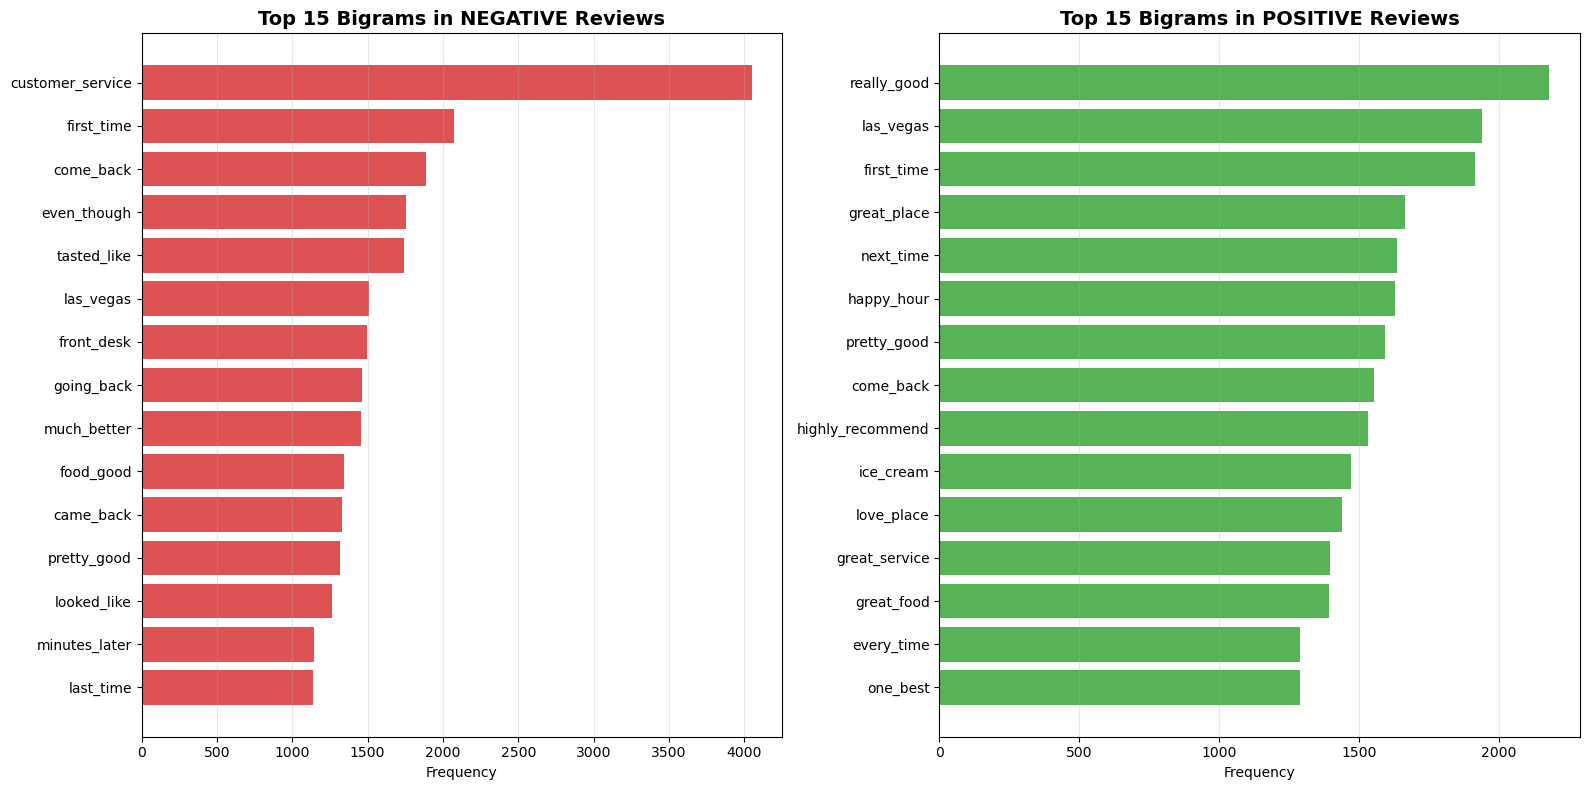


Chart saved as 'top_bigrams_by_sentiment.png'


In [24]:
# STEP 8: Visualize top bigrams
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Format bigrams as "word1_word2" for display
bigrams_neg_labels = [f"{b[0][0]}_{b[0][1]}" for b in negative_bigrams]
bigrams_neg_counts = [b[1] for b in negative_bigrams]

bigrams_pos_labels = [f"{b[0][0]}_{b[0][1]}" for b in positive_bigrams]
bigrams_pos_counts = [b[1] for b in positive_bigrams]

# Negative bigrams (left)
axes[0].barh(bigrams_neg_labels, bigrams_neg_counts, color='#d62728', alpha=0.8)
axes[0].set_xlabel('Frequency')
axes[0].set_title('Top 15 Bigrams in NEGATIVE Reviews', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Positive bigrams (right)
axes[1].barh(bigrams_pos_labels, bigrams_pos_counts, color='#2ca02c', alpha=0.8)
axes[1].set_xlabel('Frequency')
axes[1].set_title('Top 15 Bigrams in POSITIVE Reviews', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('top_bigrams_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved as 'top_bigrams_by_sentiment.png'")

In [26]:
def get_top_trigrams(text_series, n=10):
    """Extract top N trigrams after removing stopwords"""
    all_trigrams = []
    for text in text_series:
        # Tokenize and clean
        words = re.findall(r'\b[a-z]{3,}\b', text.lower())
        words = [w for w in words if w not in stop_words]
        
        # Generate trigrams
        tri_grams = list(trigrams(words))
        all_trigrams.extend(tri_grams)
    
    # Count frequencies
    trigram_counts = Counter(all_trigrams)
    return trigram_counts.most_common(n)

# Extract top trigrams for each sentiment
print("Extracting top trigrams for negative reviews...")
negative_trigrams = get_top_trigrams(df_sample[df_sample['label']==0]['text'], n=10)

print("Extracting top trigrams for positive reviews...")
positive_trigrams = get_top_trigrams(df_sample[df_sample['label']==1]['text'], n=10)

print("\n" + "="*80)
print("TOP 10 TRIGRAMS - NEGATIVE REVIEWS")
print("="*80)
for trigram, count in negative_trigrams:
    print(f"{trigram[0]:12s} {trigram[1]:12s} {trigram[2]:12s}: {count:5d}")

print("\n" + "="*80)
print("TOP 10 TRIGRAMS - POSITIVE REVIEWS")
print("="*80)
for trigram, count in positive_trigrams:
    print(f"{trigram[0]:12s} {trigram[1]:12s} {trigram[2]:12s}: {count:5d}")

Extracting top trigrams for negative reviews...
Extracting top trigrams for positive reviews...

TOP 10 TRIGRAMS - NEGATIVE REVIEWS
waste        time         money       :   245
poor         customer     service     :   241
never        come         back        :   240
horrible     customer     service     :   236
really       wanted       like        :   230
worst        service      ever        :   228
worst        customer     service     :   226
nothing      write        home        :   220
wanted       like         place       :   213
took         minutes      get         :   205

TOP 10 TRIGRAMS - POSITIVE REVIEWS
sweet        potato       fries       :   315
definitely   come         back        :   300
would        definitely   recommend   :   276
would        highly       recommend   :   267
food         great        service     :   243
great        food         great       :   233
www          yelp         com         :   222
great        customer     service     :   204
love

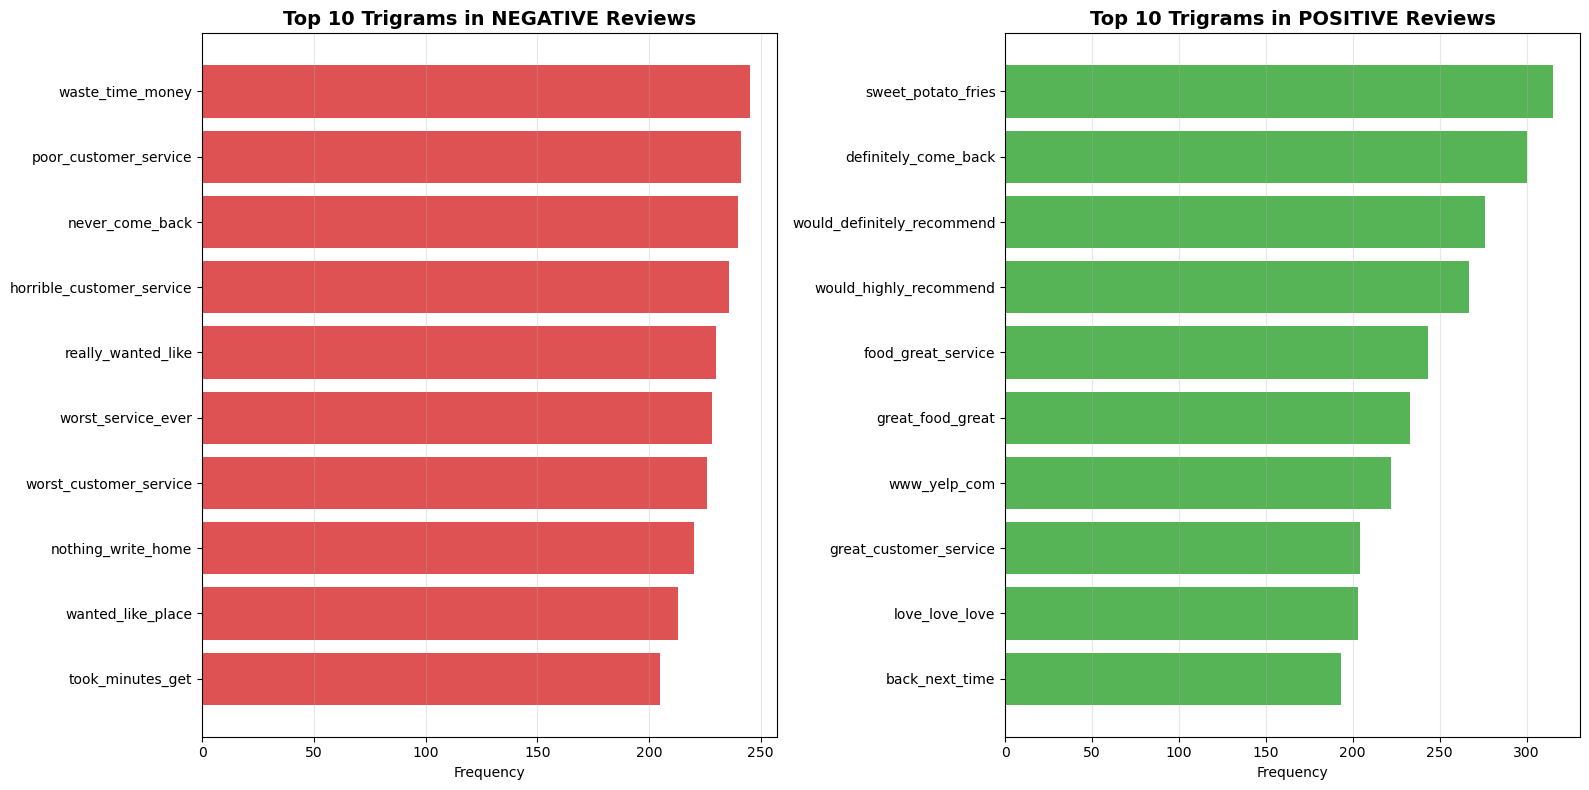


Chart saved as 'top_trigrams_by_sentiment.png'


In [28]:
# STEP 10a: Visualize top trigrams
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Format trigrams as "word1_word2_word3" for display
trigrams_neg_labels = [f"{t[0][0]}_{t[0][1]}_{t[0][2]}" for t in negative_trigrams]
trigrams_neg_counts = [t[1] for t in negative_trigrams]

trigrams_pos_labels = [f"{t[0][0]}_{t[0][1]}_{t[0][2]}" for t in positive_trigrams]
trigrams_pos_counts = [t[1] for t in positive_trigrams]

# Negative trigrams (left)
axes[0].barh(trigrams_neg_labels, trigrams_neg_counts, color='#d62728', alpha=0.8)
axes[0].set_xlabel('Frequency')
axes[0].set_title('Top 10 Trigrams in NEGATIVE Reviews', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Positive trigrams (right)
axes[1].barh(trigrams_pos_labels, trigrams_pos_counts, color='#2ca02c', alpha=0.8)
axes[1].set_xlabel('Frequency')
axes[1].set_title('Top 10 Trigrams in POSITIVE Reviews', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('top_trigrams_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved as 'top_trigrams_by_sentiment.png'")

In [30]:
# STEP 10b: Create EDA summary table
print("\n" + "="*80)
print("EDA SUMMARY — YELP REVIEWS SENTIMENT ANALYSIS")
print("="*80)

summary_data = {
    'Metric': [
        'Total Reviews Analyzed',
        'Negative Reviews',
        'Positive Reviews',
        'Avg Words (Negative)',
        'Avg Words (Positive)',
        'Median Words (Negative)',
        'Median Words (Positive)',
        'Avg Characters (Negative)',
        'Avg Characters (Positive)',
        'Unique Words (Negative)',
        'Unique Words (Positive)'
    ],
    'Value': [
        f"{len(df_sample):,}",
        f"{(df_sample['label']==0).sum():,}",
        f"{(df_sample['label']==1).sum():,}",
        f"{df_sample[df_sample['label']==0]['word_count'].mean():.1f}",
        f"{df_sample[df_sample['label']==1]['word_count'].mean():.1f}",
        f"{df_sample[df_sample['label']==0]['word_count'].median():.0f}",
        f"{df_sample[df_sample['label']==1]['word_count'].median():.0f}",
        f"{df_sample[df_sample['label']==0]['char_count'].mean():.0f}",
        f"{df_sample[df_sample['label']==1]['char_count'].mean():.0f}",
        f"{len(set(' '.join(df_sample[df_sample['label']==0]['text']).lower().split())):,}",
        f"{len(set(' '.join(df_sample[df_sample['label']==1]['text']).lower().split())):,}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)
print("- Negative reviews are ~30% longer (152 vs 115 words median)")
print("- 'customer_service' is the dominant bigram in negative reviews")
print("- 'really_good' and 'highly_recommend' are top positive bigrams")
print("- N-gram analysis justifies TF-IDF with ngram_range=(1,3)")
print("="*80)


EDA SUMMARY — YELP REVIEWS SENTIMENT ANALYSIS
                   Metric   Value
   Total Reviews Analyzed 100,000
         Negative Reviews  50,000
         Positive Reviews  50,000
     Avg Words (Negative)   152.3
     Avg Words (Positive)   114.9
  Median Words (Negative)     112
  Median Words (Positive)      84
Avg Characters (Negative)     825
Avg Characters (Positive)     634
  Unique Words (Negative) 242,639
  Unique Words (Positive) 218,640

KEY INSIGHTS
- Negative reviews are ~30% longer (152 vs 115 words median)
- 'customer_service' is the dominant bigram in negative reviews
- 'really_good' and 'highly_recommend' are top positive bigrams
- N-gram analysis justifies TF-IDF with ngram_range=(1,3)
